In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

OUTPUT_DIR = "../results/figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==============================
# 1. Load Data
# ==============================

df = pd.read_csv("../data/train.csv")
df.columns = df.columns.str.strip()

# Strip whitespace from object columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

# ==============================
# 2. Clean Target (Ratings)
# ==============================

df = df[~df["Delivery_person_Ratings"].str.contains("NaN", na=False)].copy()
df["Delivery_person_Ratings"] = pd.to_numeric(df["Delivery_person_Ratings"], errors="coerce")

# ==============================
# 3. Clean Numeric Columns
# ==============================

numeric_cols = [
    "Delivery_person_Age",
    "Vehicle_condition",
    "multiple_deliveries",
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Fill age with median
df["Delivery_person_Age"] = df["Delivery_person_Age"].fillna(
    df["Delivery_person_Age"].median()
)

# multiple deliveries
df["multiple_deliveries"] = df["multiple_deliveries"].fillna(0)

# ==============================
# 4. Clean Categorical Columns
# ==============================

df["Road_traffic_density"] = df["Road_traffic_density"].replace("NaN", np.nan)
df["Weatherconditions"] = df["Weatherconditions"].replace("NaN", np.nan)

df["Road_traffic_density"] = df["Road_traffic_density"].fillna("Unknown")
df["Weatherconditions"] = df["Weatherconditions"].fillna("Unknown")
df["Festival"] = df["Festival"].fillna("No")
df["City"] = df["City"].fillna("Unknown")

# ==============================
# 5. Clean Time_taken(min)
# ==============================

df["Time_taken(min)"] = (
    df["Time_taken(min)"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
)

df["Time_taken(min)"] = pd.to_numeric(df["Time_taken(min)"], errors="coerce")

# Drop remaining missing rows
df = df.dropna().copy()

print("Final dataset size:", len(df))


Final dataset size: 43685


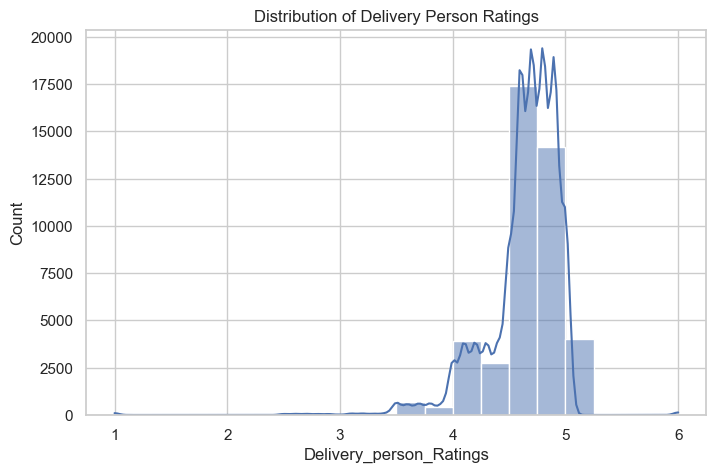

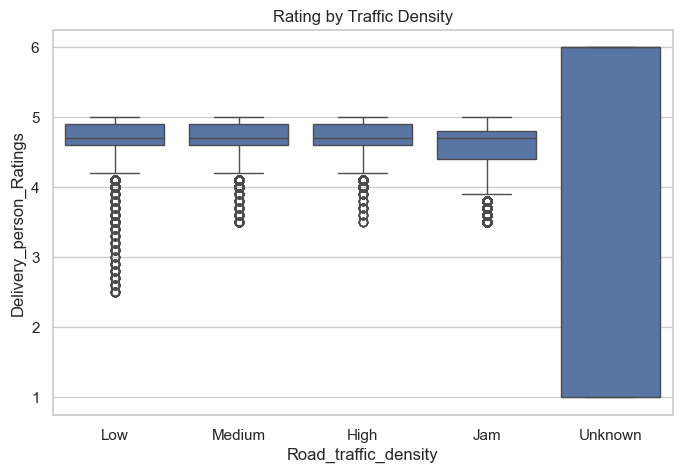

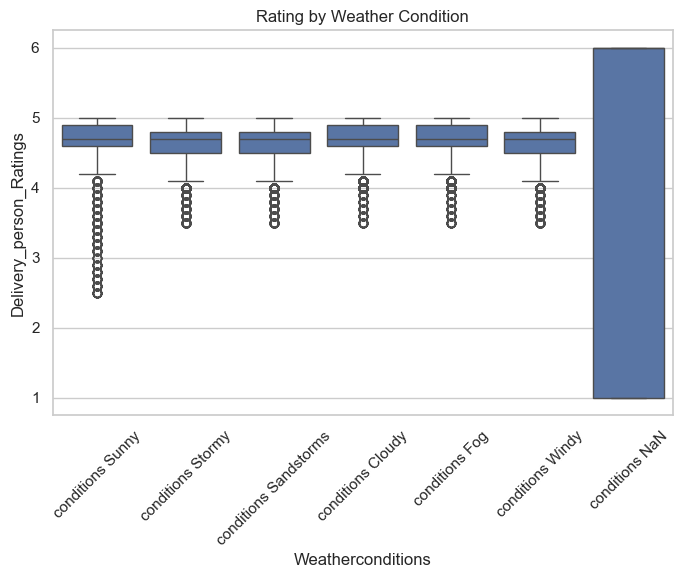

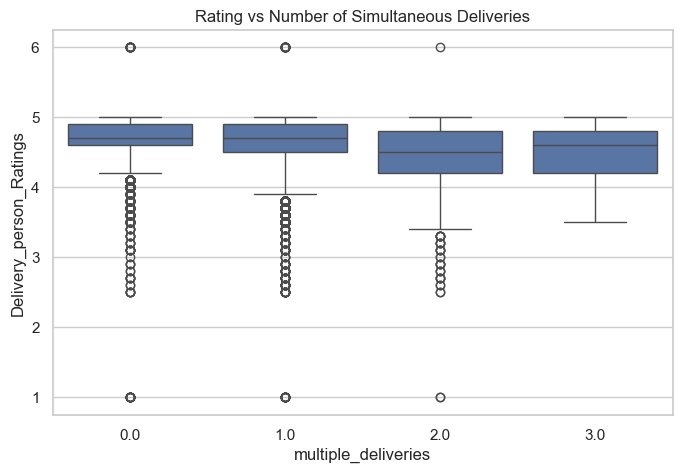

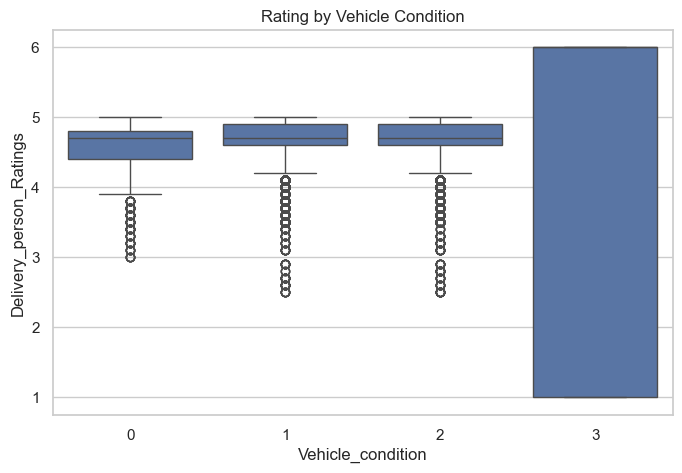

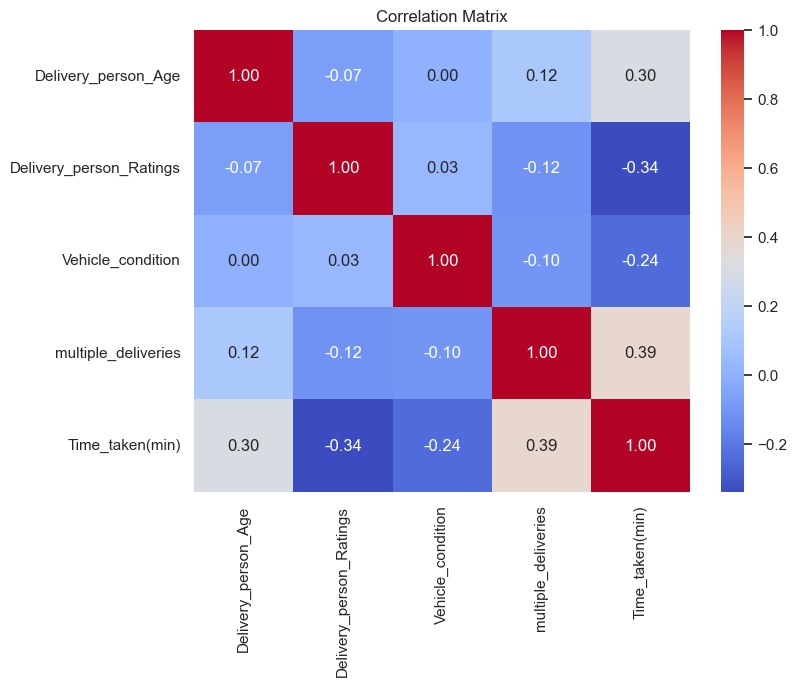

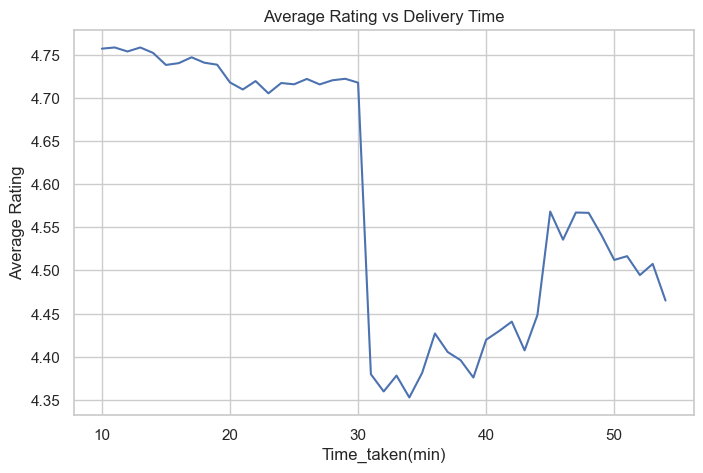

In [5]:

# ==============================
# 6. Visualization
# ==============================

sns.set(style="whitegrid")

# 1️⃣ Rating Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Delivery_person_Ratings"], bins=20, kde=True)
plt.title("Distribution of Delivery Person Ratings")
plt.savefig(f"{OUTPUT_DIR}/Delivery_Person_Ratings_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# 2️⃣ Rating by Traffic Density
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Road_traffic_density",
            y="Delivery_person_Ratings",
            order=["Low", "Medium", "High", "Jam", "Unknown"])
plt.title("Rating by Traffic Density")
plt.savefig(f"{OUTPUT_DIR}/Rating_by_Traffic_Density.png", dpi=300, bbox_inches="tight")
plt.show()

# 3️⃣ Rating by Weather
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Weatherconditions",
            y="Delivery_person_Ratings")
plt.xticks(rotation=45)
plt.title("Rating by Weather Condition")
plt.savefig(f"{OUTPUT_DIR}/Rating_by_Weather_Condition.png", dpi=300, bbox_inches="tight")
plt.show()

# 4️⃣ Rating vs Multiple Deliveries
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="multiple_deliveries",
            y="Delivery_person_Ratings")
plt.title("Rating vs Number of Simultaneous Deliveries")
plt.savefig(f"{OUTPUT_DIR}/Rating_vs_Multiple_Deliveries.png", dpi=300, bbox_inches="tight")
plt.show()

# 5️⃣ Rating by Vehicle Condition
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Vehicle_condition",
            y="Delivery_person_Ratings")
plt.title("Rating by Vehicle Condition")
plt.savefig(f"{OUTPUT_DIR}/Rating_by_Vehicle_Condition.png", dpi=300, bbox_inches="tight")
plt.show()

# ==============================
# 7. Correlation Matrix
# ==============================

numeric_cols_corr = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Vehicle_condition",
    "multiple_deliveries",
    "Time_taken(min)"
]

corr = df[numeric_cols_corr].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.savefig(f"{OUTPUT_DIR}/Correlation_Matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# ==============================
# 8. Average Rating vs Delivery Time
# ==============================

avg_rating = df.groupby("Time_taken(min)")["Delivery_person_Ratings"].mean()

plt.figure(figsize=(8,5))
plt.plot(avg_rating.index, avg_rating.values)
plt.xlabel("Time_taken(min)")
plt.ylabel("Average Rating")
plt.title("Average Rating vs Delivery Time")
plt.savefig(f"{OUTPUT_DIR}/Average_Rating_vs_Delivery_Time.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:

# ==============================
# 9. Location & City → Rating: Data Preparation
# ==============================

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df_loc = df[
    (df["Restaurant_latitude"] != 0) & (df["Restaurant_longitude"] != 0)
].copy()

df_loc["distance_km"] = haversine(
    df_loc["Restaurant_latitude"],   df_loc["Restaurant_longitude"],
    df_loc["Delivery_location_latitude"], df_loc["Delivery_location_longitude"]
)

df_loc["distance_bin"] = pd.cut(
    df_loc["distance_km"],
    bins=[0, 2, 4, 6, 8, 10, np.inf],
    labels=["0-2", "2-4", "4-6", "6-8", "8-10", "10+"]
)

city_order = sorted(df_loc["City"].dropna().unique())
print(f"df_loc size: {len(df_loc)} rows")


df_loc size: 40190 rows


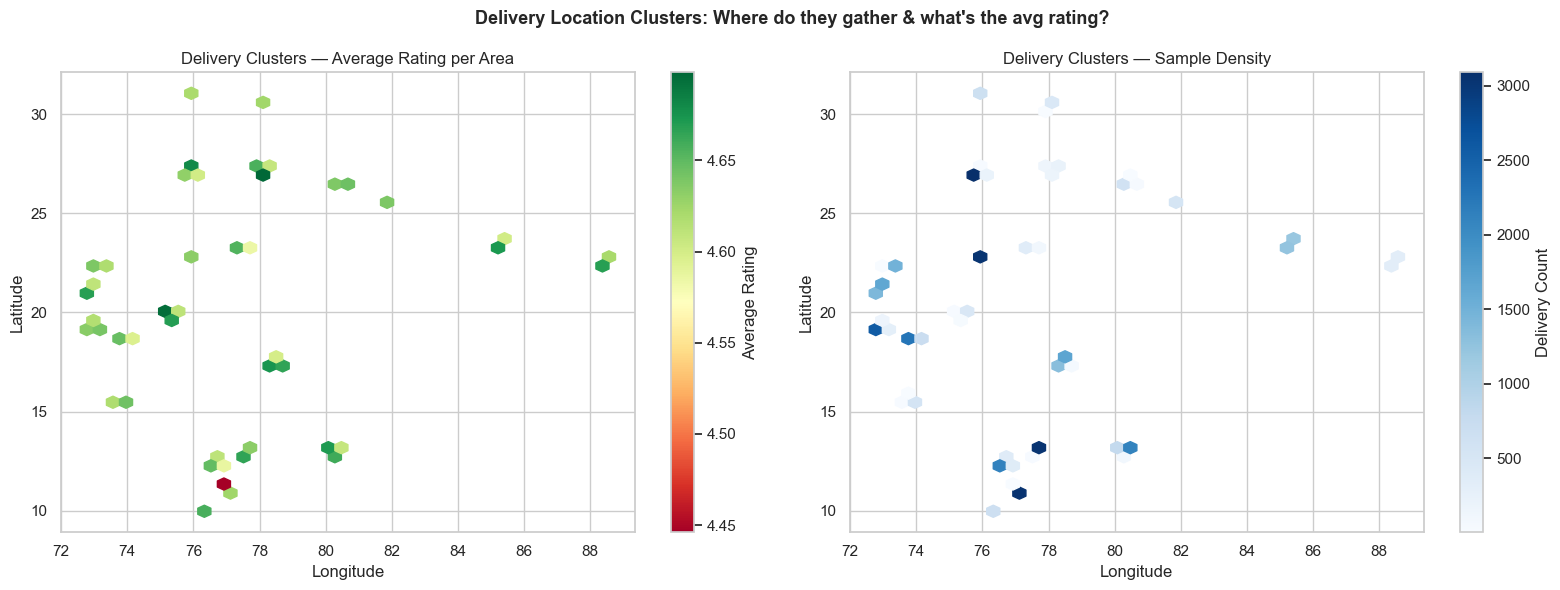

In [7]:

# 9-1. Delivery Location Clusters — Average Rating Heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

hb0 = axes[0].hexbin(
    df_loc["Delivery_location_longitude"],
    df_loc["Delivery_location_latitude"],
    C=df_loc["Delivery_person_Ratings"],
    reduce_C_function=np.mean,
    gridsize=40,
    cmap="RdYlGn",
    mincnt=10,               
)
cb0 = plt.colorbar(hb0, ax=axes[0])
cb0.set_label("Average Rating")
axes[0].set_title("Delivery Clusters — Average Rating per Area")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

hb1 = axes[1].hexbin(
    df_loc["Delivery_location_longitude"],
    df_loc["Delivery_location_latitude"],
    gridsize=40,
    cmap="Blues",
    mincnt=1,
)
cb1 = plt.colorbar(hb1, ax=axes[1])
cb1.set_label("Delivery Count")
axes[1].set_title("Delivery Clusters — Sample Density")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.suptitle("Delivery Location Clusters: Where do they gather & what's the avg rating?",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/Delivery_Cluster_Avg_Rating.png", dpi=300, bbox_inches="tight")
plt.show()


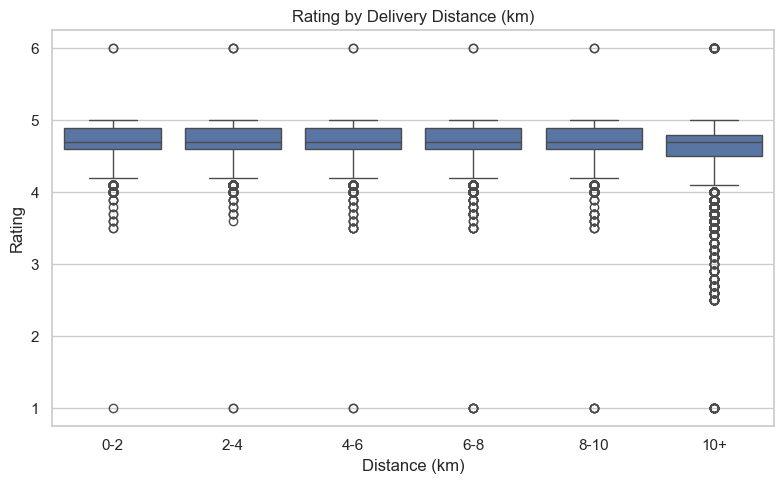

In [8]:

# 9-2. Rating by Delivery Distance (km)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_loc, x="distance_bin", y="Delivery_person_Ratings")
plt.title("Rating by Delivery Distance (km)")
plt.xlabel("Distance (km)")
plt.ylabel("Rating")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/Rating_by_Distance_Bin.png", dpi=300, bbox_inches="tight")
plt.show()


Default data path: ../data/train.csv


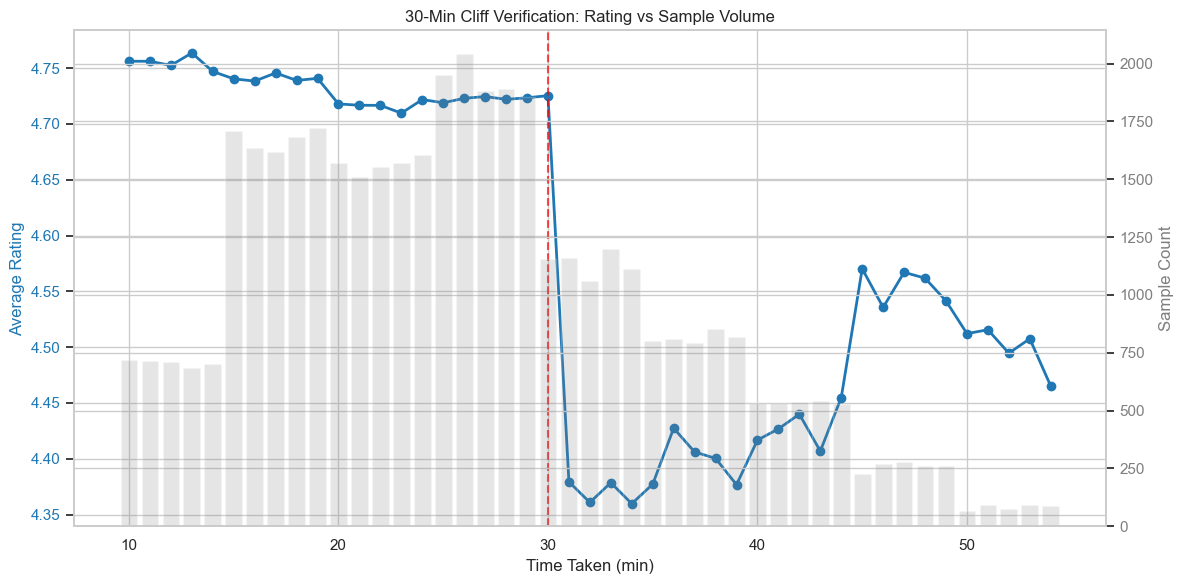

/var/folders/x8/29rdd4dn2bz5rjfq78jvtycm0000gn/T/ipykernel_1899/2337097544.py:413: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=filtered_df, x="Time_taken(min)", y="Delivery_person_Ratings", hue="Road_traffic_density", ax=ax, ci=None)


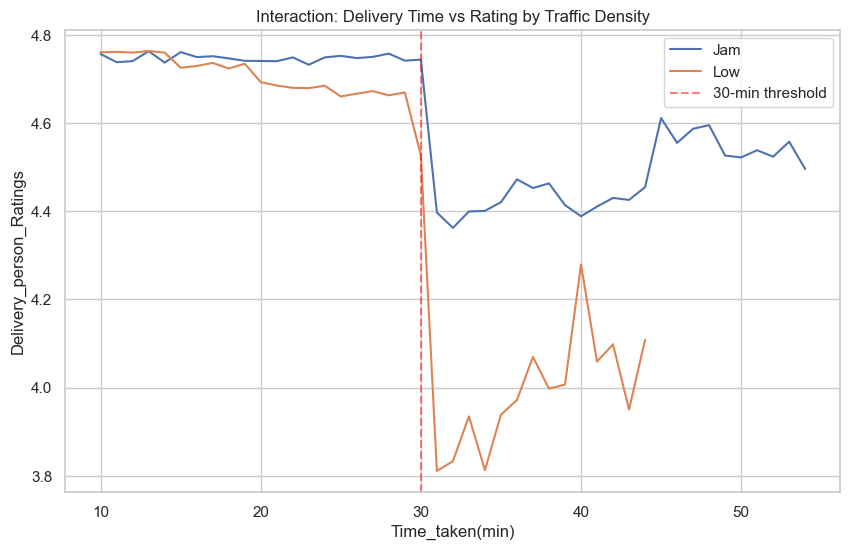

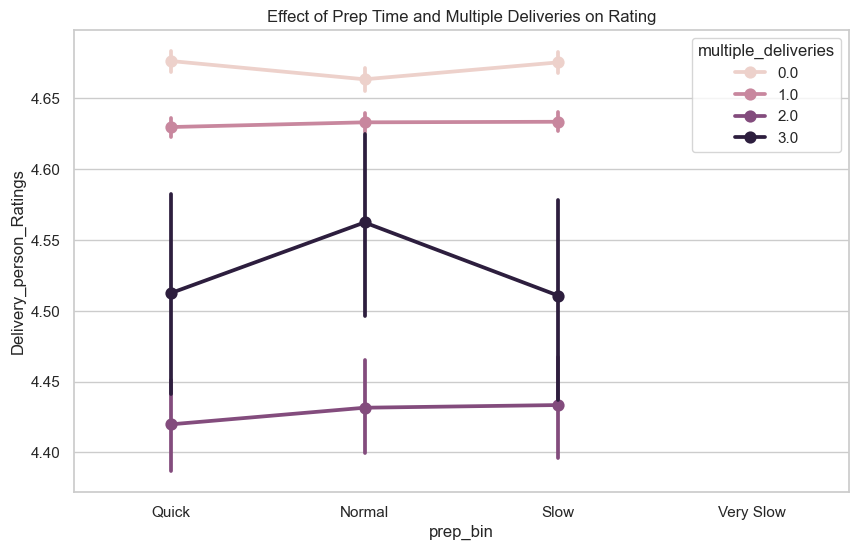

Final dataset size: 43443


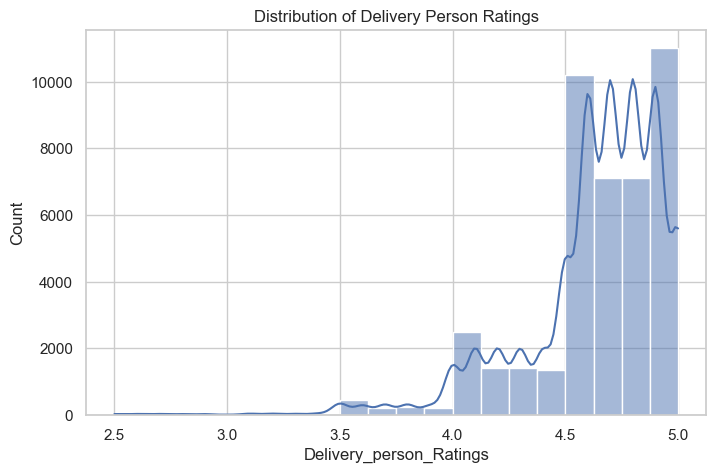

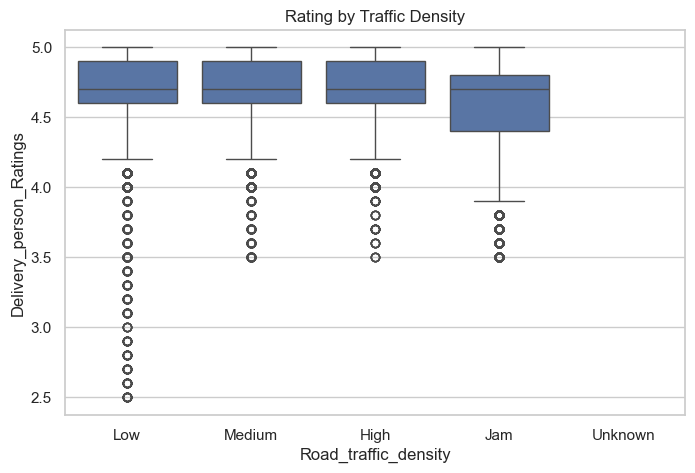

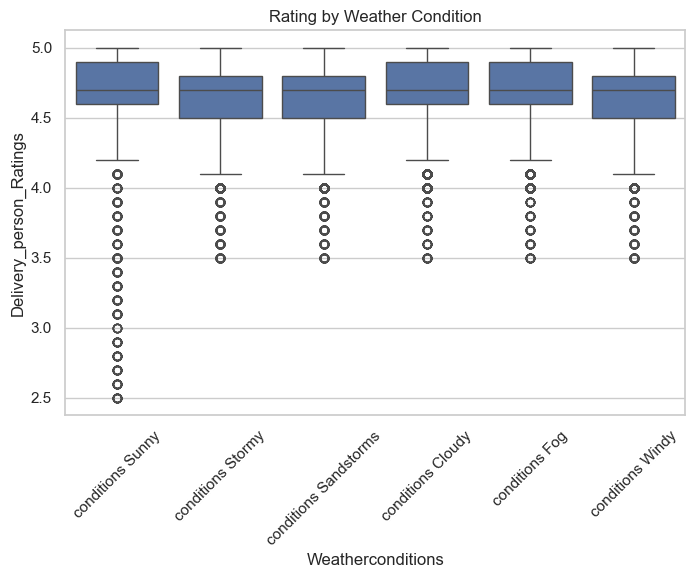

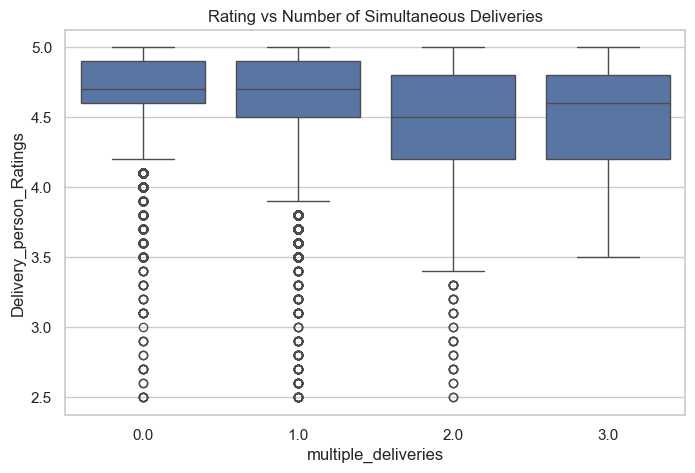

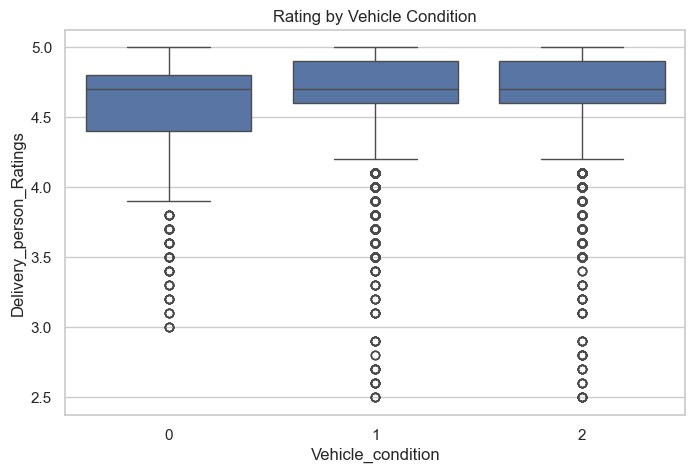

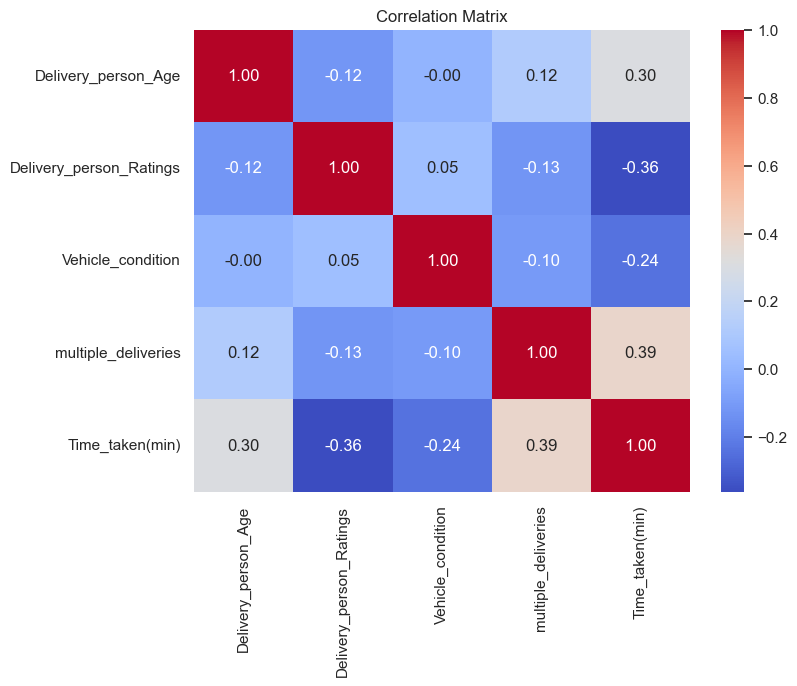

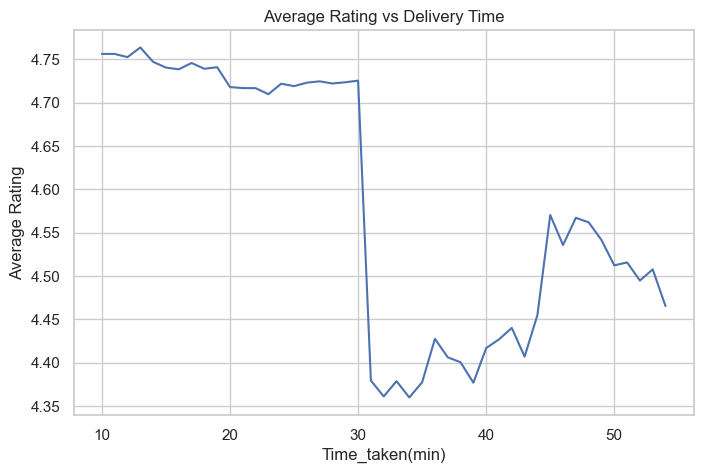

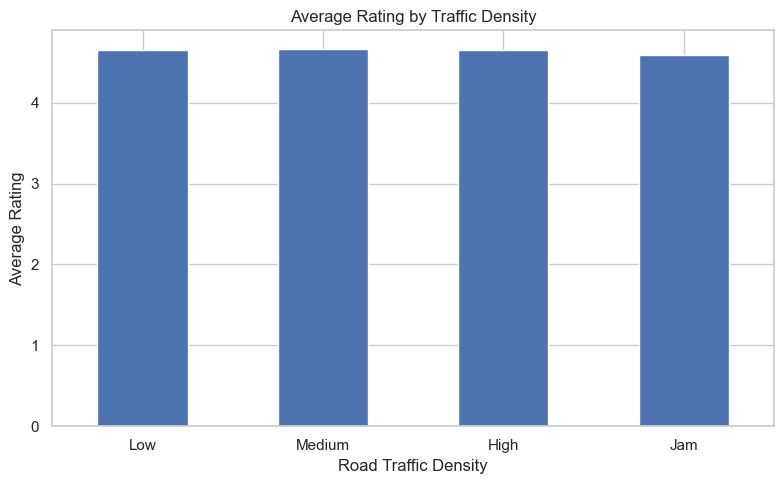

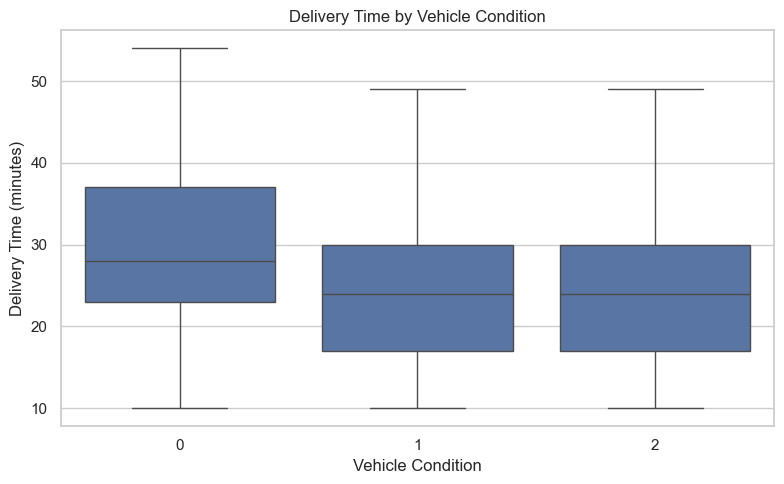

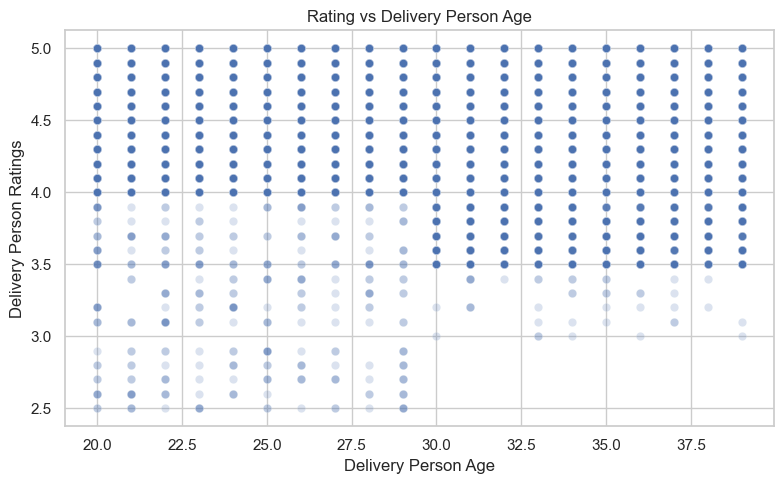

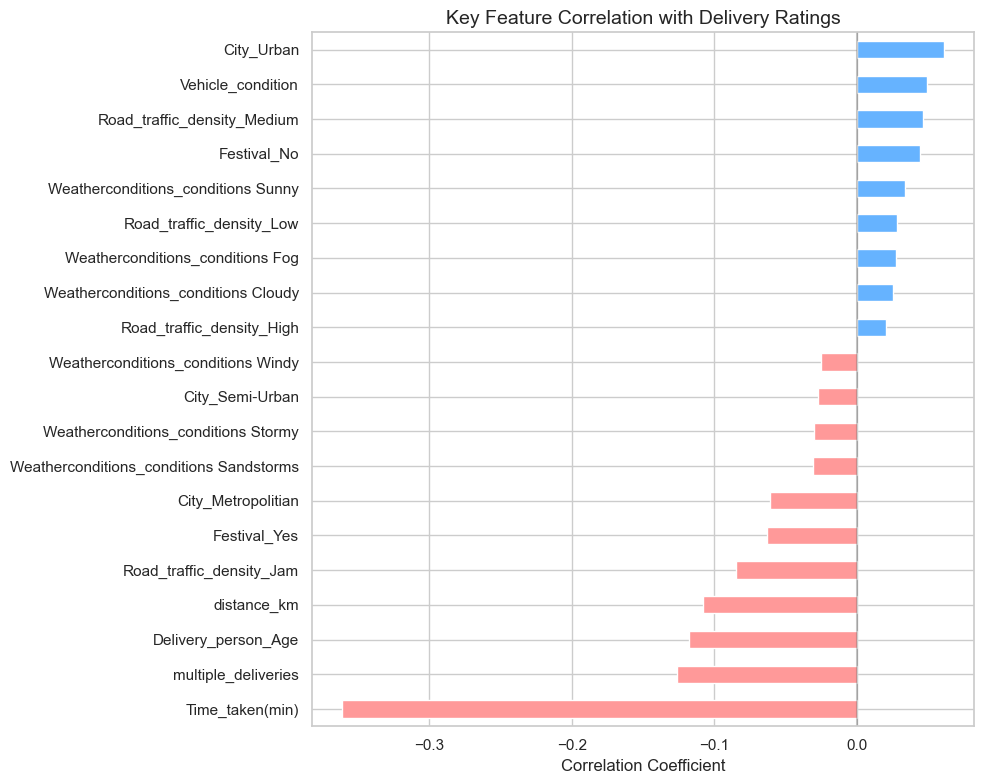

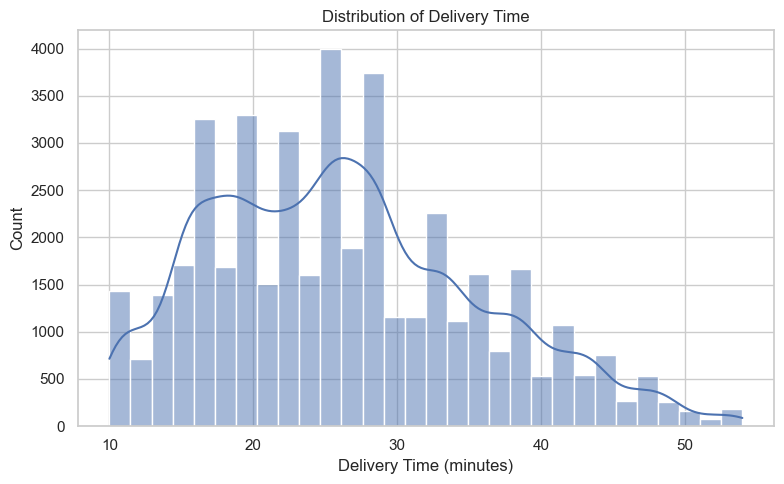

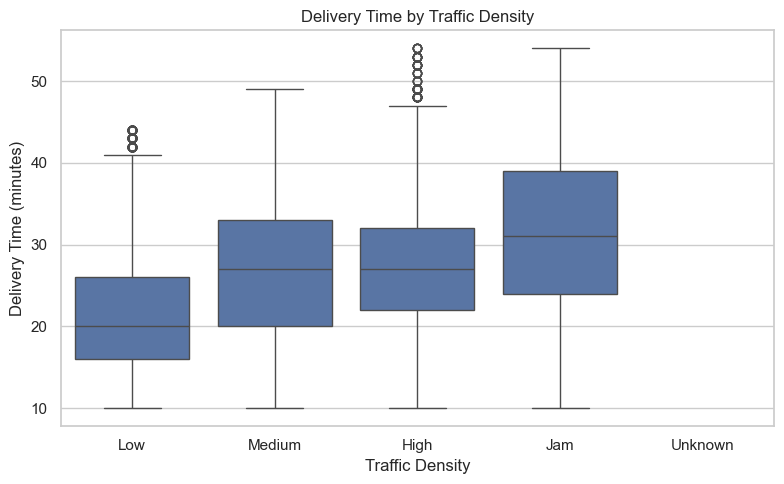

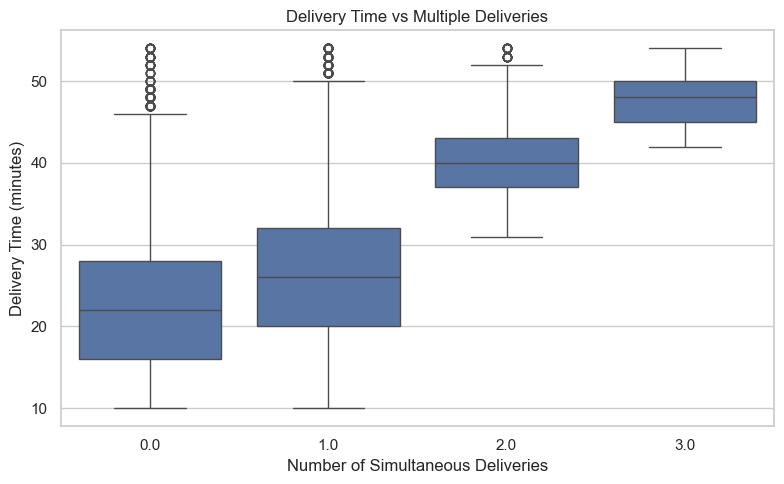

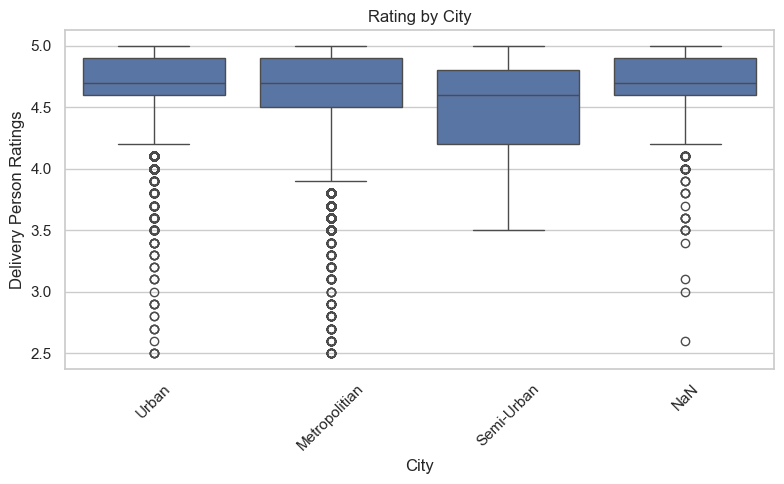

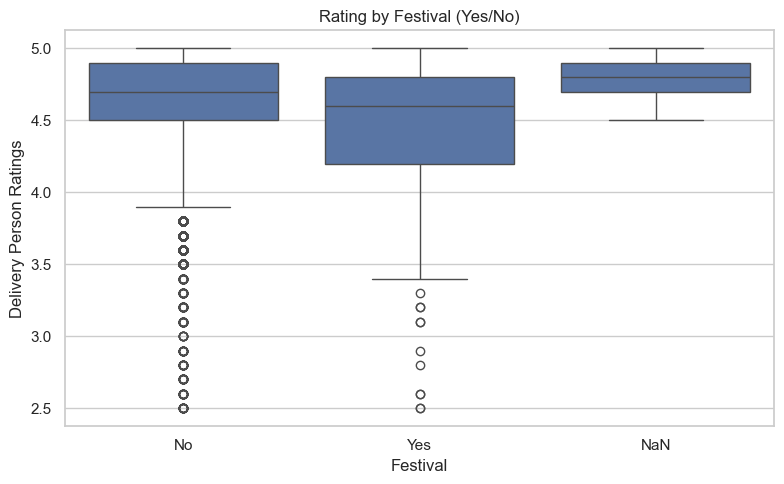

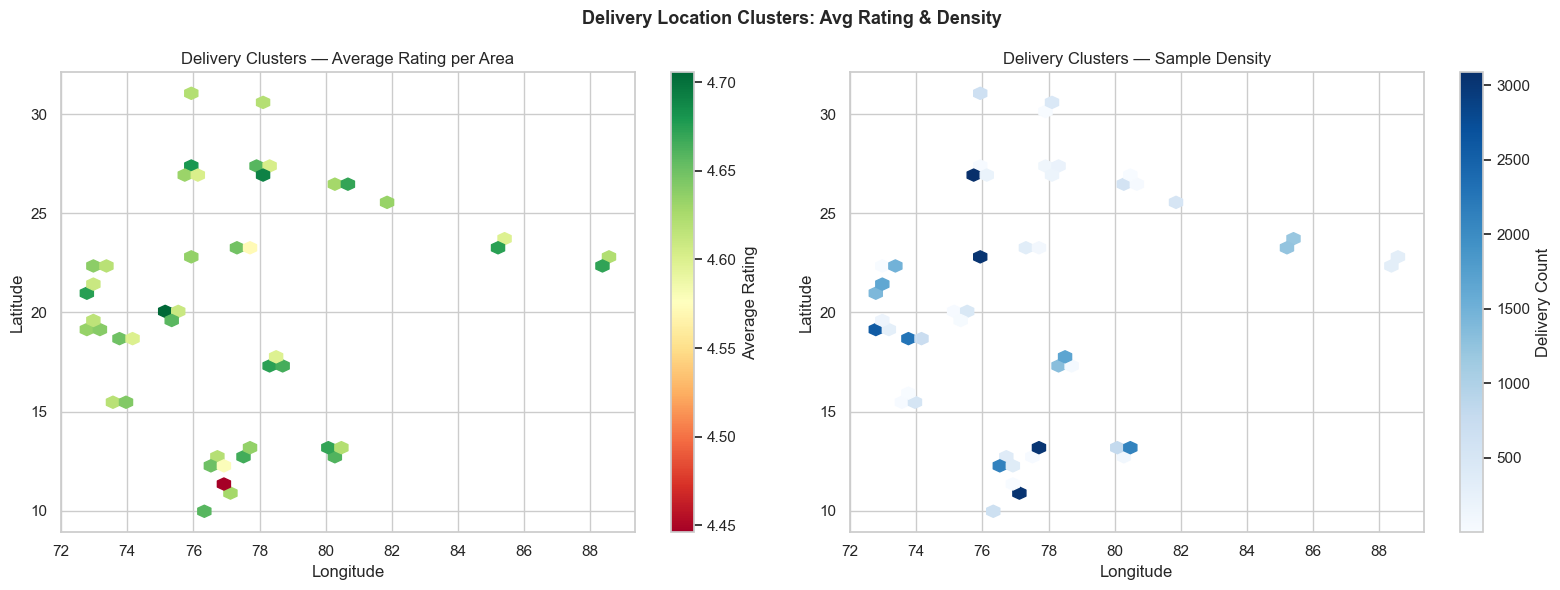

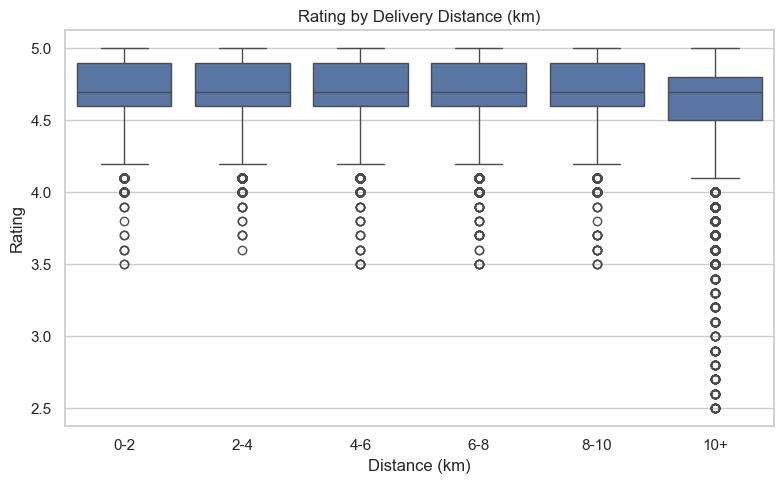

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime, timedelta

# _SCRIPT_DIR = os.getcwd()
_PROJECT_ROOT = "../" # _SCRIPT_DIR
DEFAULT_DATA_PATH = os.path.join(_PROJECT_ROOT, "data", "train.csv")
print(f"Default data path: {DEFAULT_DATA_PATH}")
DEFAULT_OUTPUT_DIR = os.path.join(_PROJECT_ROOT, "results", "figures")

# ==============================
# 1. Load & Clean Data
# ==============================


def load_and_clean_data(data_path=None):
    """
    Load train.csv and clean for visualization.
    Returns cleaned DataFrame. Use data_path when calling from notebook (e.g. "../data/train.csv").
    """
    path = data_path or DEFAULT_DATA_PATH
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()

    # Strip whitespace from string columns (avoid pandas deprecation: use string dtypes explicitly)
    for col in df.columns:
        if pd.api.types.is_string_dtype(df[col]):
            df[col] = df[col].astype(str).str.strip()

    # Clean target
    df = df[~df["Delivery_person_Ratings"].str.contains("NaN", na=False)].copy()
    df["Delivery_person_Ratings"] = pd.to_numeric(df["Delivery_person_Ratings"], errors="coerce")

    numeric_cols = [
        "Delivery_person_Age",
        "Vehicle_condition",
        "multiple_deliveries",
        "Restaurant_latitude",
        "Restaurant_longitude",
        "Delivery_location_latitude",
        "Delivery_location_longitude",
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df["Delivery_person_Age"] = df["Delivery_person_Age"].fillna(df["Delivery_person_Age"].median())
    df["multiple_deliveries"] = df["multiple_deliveries"].fillna(0)

    df["Road_traffic_density"] = df["Road_traffic_density"].replace("NaN", np.nan)
    df["Weatherconditions"] = df["Weatherconditions"].replace("NaN", np.nan)
    df["Road_traffic_density"] = df["Road_traffic_density"].fillna("Unknown")
    df["Weatherconditions"] = df["Weatherconditions"].fillna("Unknown")
    df["Festival"] = df["Festival"].fillna("No")
    df["City"] = df["City"].fillna("Unknown")

    df["Time_taken(min)"] = (
        df["Time_taken(min)"].astype(str).str.extract(r"(\d+)", expand=False)
    )
    df["Time_taken(min)"] = pd.to_numeric(df["Time_taken(min)"], errors="coerce")
    df = df.dropna().copy()
    return df


# ==============================
# 2. Core EDA Plots (save to output_dir if provided)
# ==============================

def _save(fig, name, output_dir):
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        fig.savefig(os.path.join(output_dir, name), dpi=300, bbox_inches="tight")


def plot_rating_distribution(df, output_dir=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.histplot(df["Delivery_person_Ratings"], bins=20, kde=True, ax=ax)
    ax.set_title("Distribution of Delivery Person Ratings")
    _save(fig, "Delivery_Person_Ratings_Distribution.png", output_dir)
    plt.show()
    plt.close()


def plot_rating_by_traffic(df, output_dir=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(
        data=df, x="Road_traffic_density", y="Delivery_person_Ratings",
        order=["Low", "Medium", "High", "Jam", "Unknown"], ax=ax
    )
    ax.set_title("Rating by Traffic Density")
    _save(fig, "Rating_by_Traffic_Density.png", output_dir)
    plt.show()
    plt.close()


def plot_rating_by_weather(df, output_dir=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(data=df, x="Weatherconditions", y="Delivery_person_Ratings", ax=ax)
    plt.xticks(rotation=45)
    ax.set_title("Rating by Weather Condition")
    _save(fig, "Rating_by_Weather_Condition.png", output_dir)
    plt.show()
    plt.close()


def plot_rating_by_multiple_deliveries(df, output_dir=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(data=df, x="multiple_deliveries", y="Delivery_person_Ratings", ax=ax)
    ax.set_title("Rating vs Number of Simultaneous Deliveries")
    _save(fig, "Rating_vs_Multiple_Deliveries.png", output_dir)
    plt.show()
    plt.close()


def plot_rating_by_vehicle_condition(df, output_dir=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(data=df, x="Vehicle_condition", y="Delivery_person_Ratings", ax=ax)
    ax.set_title("Rating by Vehicle Condition")
    _save(fig, "Rating_by_Vehicle_Condition.png", output_dir)
    plt.show()
    plt.close()


def plot_correlation_matrix(df, output_dir=None):
    cols = [
        "Delivery_person_Age", "Delivery_person_Ratings",
        "Vehicle_condition", "multiple_deliveries", "Time_taken(min)"
    ]
    corr = df[cols].corr()
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
    ax.set_title("Correlation Matrix")
    _save(fig, "Correlation_Matrix.png", output_dir)
    plt.show()
    plt.close()


def plot_avg_rating_vs_delivery_time(df, output_dir=None):
    avg = df.groupby("Time_taken(min)")["Delivery_person_Ratings"].mean()
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(avg.index, avg.values)
    ax.set_xlabel("Time_taken(min)")
    ax.set_ylabel("Average Rating")
    ax.set_title("Average Rating vs Delivery Time")
    _save(fig, "Average_Rating_vs_Delivery_Time.png", output_dir)
    plt.show()
    plt.close()


# ==============================
# 3. Extra report-friendly plots
# ==============================

def plot_avg_rating_by_traffic_bar(df, output_dir=None):
    avg = df.groupby("Road_traffic_density")["Delivery_person_Ratings"].mean()
    order = ["Low", "Medium", "High", "Jam", "Unknown"]
    avg = avg.reindex(order).dropna()
    fig, ax = plt.subplots(figsize=(8, 5))
    avg.plot(kind="bar", ax=ax)
    ax.set_title("Average Rating by Traffic Density")
    ax.set_ylabel("Average Rating")
    ax.set_xlabel("Road Traffic Density")
    ax.set_xticklabels(avg.index, rotation=0)
    plt.tight_layout()
    _save(fig, "Average_Rating_by_Traffic_Bar.png", output_dir)
    plt.show()
    plt.close()


def plot_delivery_time_by_vehicle(df, output_dir=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(data=df, x="Vehicle_condition", y="Time_taken(min)", ax=ax)
    ax.set_title("Delivery Time by Vehicle Condition")
    ax.set_xlabel("Vehicle Condition")
    ax.set_ylabel("Delivery Time (minutes)")
    plt.tight_layout()
    _save(fig, "Delivery_Time_by_Vehicle_Condition.png", output_dir)
    plt.show()
    plt.close()


def plot_rating_vs_age_scatter(df, output_dir=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.scatterplot(data=df, x="Delivery_person_Age", y="Delivery_person_Ratings", alpha=0.2, ax=ax)
    ax.set_title("Rating vs Delivery Person Age")
    ax.set_xlabel("Delivery Person Age")
    ax.set_ylabel("Delivery Person Ratings")
    plt.tight_layout()
    _save(fig, "Rating_vs_Age_Scatter.png", output_dir)
    plt.show()
    plt.close()


def plot_feature_correlation_with_rating(df, output_dir=None):
    if 'distance_km' not in df.columns:
        df['distance_km'] = _haversine(
            df["Restaurant_latitude"], df["Restaurant_longitude"],
            df["Delivery_location_latitude"], df["Delivery_location_longitude"]
        )

    categorical_cols = ["Road_traffic_density", "Weatherconditions", "City", "Festival"]
    numeric_cols = ["Delivery_person_Ratings", "Delivery_person_Age", "Vehicle_condition", 
                    "multiple_deliveries", "Time_taken(min)", "distance_km"]

    df_for_corr = pd.get_dummies(df[numeric_cols + categorical_cols], columns=categorical_cols, dtype=int)
    rating_corr = df_for_corr.corr()["Delivery_person_Ratings"].drop("Delivery_person_Ratings").sort_values()
    rating_corr = rating_corr[~rating_corr.index.str.contains('NaN|Unknown', case=False)]
    rating_corr = rating_corr[rating_corr.abs() > 0.01]
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ['#ff9999' if x < 0 else '#66b3ff' for x in rating_corr]
    rating_corr.plot(kind="barh", color=colors, ax=ax)
    
    ax.set_title("Key Feature Correlation with Delivery Ratings", fontsize=14)
    ax.set_xlabel("Correlation Coefficient")
    plt.axvline(x=0, color='black', linestyle='-', alpha=0.2)
    plt.tight_layout()
    
    _save(fig, "Feature_Correlation_with_Rating_Cleaned.png", output_dir)
    plt.show()
    plt.close()


def plot_delivery_time_distribution(df, output_dir=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.histplot(df["Time_taken(min)"], bins=30, kde=True, ax=ax)
    ax.set_title("Distribution of Delivery Time")
    ax.set_xlabel("Delivery Time (minutes)")
    ax.set_ylabel("Count")
    plt.tight_layout()
    _save(fig, "Delivery_Time_Distribution.png", output_dir)
    plt.show()
    plt.close()


def plot_delivery_time_by_traffic(df, output_dir=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(
        data=df, x="Road_traffic_density", y="Time_taken(min)",
        order=["Low", "Medium", "High", "Jam", "Unknown"], ax=ax
    )
    ax.set_title("Delivery Time by Traffic Density")
    ax.set_xlabel("Traffic Density")
    ax.set_ylabel("Delivery Time (minutes)")
    plt.tight_layout()
    _save(fig, "Delivery_Time_by_Traffic.png", output_dir)
    plt.show()
    plt.close()


def plot_delivery_time_by_multiple_deliveries(df, output_dir=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(data=df, x="multiple_deliveries", y="Time_taken(min)", ax=ax)
    ax.set_title("Delivery Time vs Multiple Deliveries")
    ax.set_xlabel("Number of Simultaneous Deliveries")
    ax.set_ylabel("Delivery Time (minutes)")
    plt.tight_layout()
    _save(fig, "Delivery_Time_vs_Multiple_Deliveries.png", output_dir)
    plt.show()
    plt.close()


def plot_rating_by_city(df, output_dir=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(data=df, x="City", y="Delivery_person_Ratings", ax=ax)
    plt.xticks(rotation=45)
    ax.set_title("Rating by City")
    ax.set_xlabel("City")
    ax.set_ylabel("Delivery Person Ratings")
    plt.tight_layout()
    _save(fig, "Rating_by_City.png", output_dir)
    plt.show()
    plt.close()


def plot_rating_by_festival(df, output_dir=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(data=df, x="Festival", y="Delivery_person_Ratings", ax=ax)
    ax.set_title("Rating by Festival (Yes/No)")
    ax.set_xlabel("Festival")
    ax.set_ylabel("Delivery Person Ratings")
    plt.tight_layout()
    _save(fig, "Rating_by_Festival.png", output_dir)
    plt.show()
    plt.close()


def run_all_visualizations(df, output_dir=None):
    """Run all EDA and report-friendly plots and optionally save figures."""
    sns.set(style="whitegrid")
    plot_rating_distribution(df, output_dir)
    plot_rating_by_traffic(df, output_dir)
    plot_rating_by_weather(df, output_dir)
    plot_rating_by_multiple_deliveries(df, output_dir)
    plot_rating_by_vehicle_condition(df, output_dir)
    plot_correlation_matrix(df, output_dir)
    plot_avg_rating_vs_delivery_time(df, output_dir)
    plot_avg_rating_by_traffic_bar(df, output_dir)
    plot_delivery_time_by_vehicle(df, output_dir)
    plot_rating_vs_age_scatter(df, output_dir)
    plot_feature_correlation_with_rating(df, output_dir)
    plot_delivery_time_distribution(df, output_dir)
    plot_delivery_time_by_traffic(df, output_dir)
    plot_delivery_time_by_multiple_deliveries(df, output_dir)
    plot_rating_by_city(df, output_dir)
    plot_rating_by_festival(df, output_dir)


# ==============================
# 4. Location / Distance plots (optional)
# ==============================

def _haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))


def get_location_dataframe(df):
    """Build df_loc with distance_km and distance_bin for location plots."""
    df_loc = df[
        (df["Restaurant_latitude"] != 0) & (df["Restaurant_longitude"] != 0)
    ].copy()
    df_loc["distance_km"] = _haversine(
        df_loc["Restaurant_latitude"], df_loc["Restaurant_longitude"],
        df_loc["Delivery_location_latitude"], df_loc["Delivery_location_longitude"]
    )
    df_loc["distance_bin"] = pd.cut(
        df_loc["distance_km"],
        bins=[0, 2, 4, 6, 8, 10, np.inf],
        labels=["0-2", "2-4", "4-6", "6-8", "8-10", "10+"]
    )
    return df_loc


def plot_delivery_cluster_heatmap(df, output_dir=None):
    df_loc = get_location_dataframe(df)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    hb0 = axes[0].hexbin(
        df_loc["Delivery_location_longitude"], df_loc["Delivery_location_latitude"],
        C=df_loc["Delivery_person_Ratings"], reduce_C_function=np.mean,
        gridsize=40, cmap="RdYlGn", mincnt=10,
    )
    plt.colorbar(hb0, ax=axes[0]).set_label("Average Rating")
    axes[0].set_title("Delivery Clusters — Average Rating per Area")
    axes[0].set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")
    hb1 = axes[1].hexbin(
        df_loc["Delivery_location_longitude"], df_loc["Delivery_location_latitude"],
        gridsize=40, cmap="Blues", mincnt=1,
    )
    plt.colorbar(hb1, ax=axes[1]).set_label("Delivery Count")
    axes[1].set_title("Delivery Clusters — Sample Density")
    axes[1].set_xlabel("Longitude")
    axes[1].set_ylabel("Latitude")
    fig.suptitle("Delivery Location Clusters: Avg Rating & Density", fontsize=13, fontweight="bold")
    plt.tight_layout()
    _save(fig, "Delivery_Cluster_Avg_Rating.png", output_dir)
    plt.show()
    plt.close()


def plot_rating_by_distance_bin(df, output_dir=None):
    df_loc = get_location_dataframe(df)
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(data=df_loc, x="distance_bin", y="Delivery_person_Ratings", ax=ax)
    ax.set_title("Rating by Delivery Distance (km)")
    ax.set_xlabel("Distance (km)")
    ax.set_ylabel("Rating")
    plt.tight_layout()
    _save(fig, "Rating_by_Distance_Bin.png", output_dir)
    plt.show()
    plt.close()


def run_location_visualizations(df, output_dir=None):
    """Run location/distance-based plots."""
    plot_delivery_cluster_heatmap(df, output_dir)
    plot_rating_by_distance_bin(df, output_dir)


def load_and_clean_data_v2(data_path=None):
    df = load_and_clean_data(data_path)
    df = df[df['Time_Orderd'] != 'NaN'].copy()
    df = df[df['Time_Order_picked'] != 'NaN'].copy()
    def calculate_time_diff(row):
        try:
            fmt = '%H:%M:%S'
            t1 = datetime.strptime(row['Time_Orderd'], fmt)
            t2 = datetime.strptime(row['Time_Order_picked'], fmt)
            diff = (t2 - t1).total_seconds() / 60
            if diff < 0: diff += 1440
            return diff
        except:
            return np.nan
    df['prep_time_min'] = df.apply(calculate_time_diff, axis=1)
    df['distance_km'] = _haversine(
        df["Restaurant_latitude"], df["Restaurant_longitude"],
        df["Delivery_location_latitude"], df["Delivery_location_longitude"]
    )
    df = df[(df['distance_km'] > 0) & (df['distance_km'] < 50)].copy()
    return df

def plot_delivery_time_interaction(df, output_dir=None):
    fig, ax = plt.subplots(figsize=(10, 6))
    target_traffic = ['Low', 'Jam']
    filtered_df = df[df['Road_traffic_density'].isin(target_traffic)]
    sns.lineplot(data=filtered_df, x="Time_taken(min)", y="Delivery_person_Ratings", hue="Road_traffic_density", ax=ax, ci=None)
    ax.set_title("Interaction: Delivery Time vs Rating by Traffic Density")
    ax.axvline(x=30, color='red', linestyle='--', alpha=0.5, label='30-min threshold')
    ax.legend()
    _save(fig, "Deep_Analysis_Traffic_Interaction.png", output_dir)
    plt.show()

def plot_prep_vs_delivery_effect(df, output_dir=None):
    df['prep_bin'] = pd.cut(df['prep_time_min'], bins=[0, 5, 10, 15, 20], labels=['Quick', 'Normal', 'Slow', 'Very Slow'])
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.pointplot(data=df, x="prep_bin", y="Delivery_person_Ratings", hue="multiple_deliveries", ax=ax)
    ax.set_title("Effect of Prep Time and Multiple Deliveries on Rating")
    _save(fig, "Deep_Analysis_Prep_Effect.png", output_dir)
    plt.show()

def plot_30min_cliff_verification(df, output_dir=None):
    avg_rating = df.groupby("Time_taken(min)")["Delivery_person_Ratings"].mean()
    counts = df.groupby("Time_taken(min)")["ID"].count()
    fig, ax1 = plt.subplots(figsize=(12, 6))
    color = 'tab:blue'
    ax1.set_xlabel('Time Taken (min)')
    ax1.set_ylabel('Average Rating', color=color)
    ax1.plot(avg_rating.index, avg_rating.values, color=color, linewidth=2, marker='o', label='Avg Rating')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.axvline(x=30, color='red', linestyle='--', alpha=0.7)

    ax2 = ax1.twinx()
    color = 'tab:gray'
    ax2.set_ylabel('Sample Count', color=color)
    ax2.bar(counts.index, counts.values, color=color, alpha=0.2, label='Sample Count')
    ax2.tick_params(axis='y', labelcolor=color)
    
    plt.title("30-Min Cliff Verification: Rating vs Sample Volume")
    fig.tight_layout()
    _save(fig, "Deep_Analysis_Cliff_Verification.png", output_dir)
    plt.show()

df = load_and_clean_data_v2()
plot_30min_cliff_verification(df, DEFAULT_OUTPUT_DIR)
plot_delivery_time_interaction(df, DEFAULT_OUTPUT_DIR)
plot_prep_vs_delivery_effect(df, DEFAULT_OUTPUT_DIR)
# df = load_and_clean_data()
print("Final dataset size:", len(df))
run_all_visualizations(df, DEFAULT_OUTPUT_DIR)
run_location_visualizations(df, DEFAULT_OUTPUT_DIR)


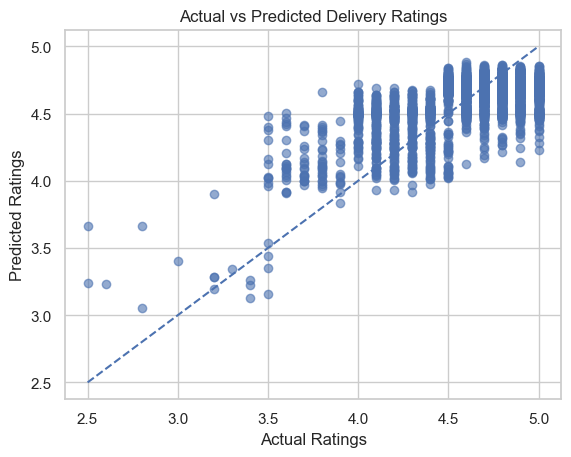

In [13]:
df = pd.read_csv("../results/data/mlp_predictions.csv")
actual = df["Actual"]
preds = df["Predicted"]
plt.figure()

plt.scatter(actual, preds, alpha=0.6)

min_val = min(actual.min(), preds.min())
max_val = max(actual.max(), preds.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Delivery Ratings")

plt.show()

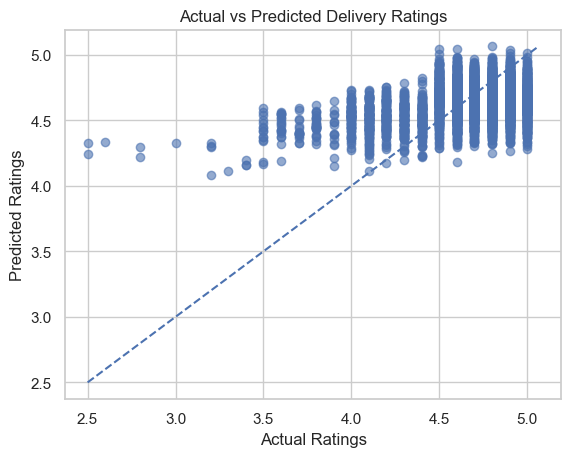

In [14]:
df = pd.read_csv("../results/data/linear_predictions.csv")
actual = df["Actual"]
preds = df["Predicted"]
plt.figure()

plt.scatter(actual, preds, alpha=0.6)

min_val = min(actual.min(), preds.min())
max_val = max(actual.max(), preds.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Delivery Ratings")

plt.show()